In [28]:
import csv
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import pandas as pd
import random
import requests
import numpy as np
import time
import math
import collections
from statistics import mean

In [29]:
# Given by tutoring staff, not participants
import os, gzip, shutil, urllib.request

def download_and_extract(url, out_path):
    """Download a .gz file and decompress it to out_path. Pure Python, works on any OS."""
    if os.path.exists(out_path):
        print(f"'{out_path}' is already here - skipping download.")
        return out_path

    gz_path = out_path + ".gz"
    print(f"Downloading {url}")
    # Some servers reject the default urllib agent, so we set a browser-like one.
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as resp, open(gz_path, "wb") as f:
        shutil.copyfileobj(resp, f)

    print("Decompressing...")
    with gzip.open(gz_path, "rb") as f_in, open(out_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(gz_path)                      # drop the .gz, keep the plain file

    print("Ready:", os.path.abspath(out_path))
    return out_path

print("Working folder:", os.getcwd())

Working folder: /home/belugaboy/Schreibtisch/Biomed Data Science/Project/ChG-Interdecagon-Analysis-Summer-School-Team-Project-


In [30]:
# Given by tutoring staff, not participants
path = download_and_extract(
    "https://snap.stanford.edu/biodata/datasets/10016/files/ChG-InterDecagon_targets.csv.gz",
    "ChG-InterDecagon_targets.csv",
)


print("--- first 10 lines ---")
with open(path, "r") as f:
    for _ in range(10):
        print(f.readline().rstrip())

# Let Python's Sniffer guess the format from a small sample
with open(path, "r") as f:
    sample = f.read(2048)

dialect = csv.Sniffer().sniff(sample)
has_header = csv.Sniffer().has_header(sample)
print(f"\nDetected delimiter: {dialect.delimiter!r}")
print("Header row present:", has_header)


'ChG-InterDecagon_targets.csv' is already here - skipping download.
--- first 10 lines ---
# Drug	Gene
CID000060752,3757
CID006918155,2908
CID103052762,3359
CID023668479,1230
CID000028864,1269
CID000028864,124274
CID000028864,2849
CID000028864,2847
CID000028864,2844

Detected delimiter: 'D'
Header row present: False


In [31]:
# Use pandas to read the edge list (skip commented header) and build a bipartite graph
df = pd.read_csv(path, comment='#', header=None, names=['drug', 'gene'], dtype=str)

B = nx.Graph()
drugs = df['drug'].unique()
genes = df['gene'].unique()
B.add_nodes_from(drugs, bipartite=0, type='drug')
B.add_nodes_from(genes, bipartite=1, type='gene')
B.add_edges_from(df[['drug', 'gene']].itertuples(index=False, name=None))

print(f"Bipartite graph created: {B.number_of_nodes()} nodes, {B.number_of_edges()} edges")

Bipartite graph created: 9569 nodes, 131034 edges


In [32]:
def calculate_network_metrics(B, drug_list=None, gene_list=None):
    """
    Calculates and prints basic network metrics for a given bipartite graph B.
    Args:
        B (networkx.Graph): The bipartite graph for which to calculate metrics.
        drug_list (list): List of top (drug) nodes. If None, inferred from graph metadata.
        gene_list (list): List of bottom (gene) nodes. If None, inferred from graph metadata.
    """
    # Infer partitions from graph metadata if not provided
    if drug_list is None or gene_list is None:
        top_nodes, bottom_nodes = nx.bipartite.sets(B)
    else:
        top_nodes    = set(drug_list) & set(B.nodes())
        bottom_nodes = set(gene_list) & set(B.nodes())

    # Degrees per partition
    degree_map     = dict(nx.degree(B))
    top_degrees    = {n: degree_map[n] for n in top_nodes}
    bottom_degrees = {n: degree_map[n] for n in bottom_nodes}

    avg_degree        = mean(degree_map.values())     if degree_map     else 0.0
    avg_top_degree    = mean(top_degrees.values())    if top_degrees    else 0.0
    avg_bottom_degree = mean(bottom_degrees.values()) if bottom_degrees else 0.0

    density        = nx.bipartite.density(B, top_nodes)
    avg_clustering = nx.bipartite.average_clustering(B, mode="min")  # no intermediate dict

    print("--- Network Metrics (Bipartite) ---")
    print(f"Partition sizes: drugs={len(top_nodes)}, genes={len(bottom_nodes)}")
    print("Average Degree (all nodes):", avg_degree)
    print("Average Degree (drugs)    :", avg_top_degree)
    print("Average Degree (genes)    :", avg_bottom_degree)
    print("Bipartite Density         :", density)
    print("Average Clustering        :", avg_clustering)
    print("-----------------------------------")

    return {
        "avg_degree":        avg_degree,
        "avg_top_degree":    avg_top_degree,
        "avg_bottom_degree": avg_bottom_degree,
        "density":           density,
        "avg_clustering":    avg_clustering,
    }

In [33]:
def analyze_components(B):
    """
    Analyzes connected components of an undirected bipartite graph B.
    Args:
        B (networkx.Graph): The bipartite graph to analyze.
    """
    components = list(nx.connected_components(B))

    num_components   = len(components)
    largest_comp     = max(components, key=len)
    largest_comp_size = len(largest_comp)

    print("--- Connected Components ---")
    print("Number of components      :", num_components)
    print("Largest component (nodes) :", largest_comp_size)
    print("---------------------------")

    return {
        "components":        components,
        "num_components":    num_components,
        "largest_comp_size": largest_comp_size,
        "largest_comp":      largest_comp,      # node set, useful for subgraph extraction
    }

In [34]:
def centrality_measures(G):
    """
    Calculates Betweenness, Closeness, and Eigenvector centrality
    for a NetworkX graph using approximated methods.
    """
    # k=300 samples takes about 2 mins
    print("Computing Betweenness Centrality (Approximated)...")
    betweenness = nx.betweenness_centrality(G, k=300)
    avg_betweenness = sum(betweenness.values()) / len(betweenness)
    print("Average Betweenness Centrality:", avg_betweenness)
    print("Computing Closeness Centrality...")
    closeness = nx.closeness_centrality(G)
    print(closeness)
    avg = sum(closeness.values()) / len(closeness)
    print("Average Closeness Centrality:", avg)
    print("Computing Eigenvector Centrality...")
    try:
        eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
        print(eigenvector)
        avg = sum(eigenvector.values()) / len(eigenvector)
        print("Average Eigenvector Centrality:", avg)
    except nx.PowerIterationFailedConvergence:
        print("Warning: Eigenvector centrality failed to converge. Returning None.")
        eigenvector = {node: None for node in G.nodes()}

    return betweenness, closeness, eigenvector

In [35]:
def visualize_components(B, drug_list, gene_list, max_components=10):
    """
    Visualizes connected components of a bipartite graph, coloring drugs and genes differently.
    Args:
        B (networkx.Graph): The bipartite graph.
        drug_list (list): List of drug nodes.
        gene_list (list): List of gene nodes.
        max_components (int): Max number of components to plot (by descending size).
    """
    drug_set = set(drug_list)
    gene_set = set(gene_list)

    # Sort components by size descending
    components = sorted(nx.connected_components(B), key=len, reverse=True)
    components_to_plot = components[:max_components]

    n = len(components_to_plot)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, comp in enumerate(components_to_plot):
        ax = axes[i]
        subgraph = B.subgraph(comp)

        top    = [n for n in comp if n in drug_set]
        bottom = [n for n in comp if n in gene_set]

        # Bipartite layout: drugs on left, genes on right
        pos = nx.bipartite_layout(subgraph, top, align="horizontal")

        node_colors = ["#e05c5c" if n in drug_set else "#5c9ee0" for n in subgraph.nodes()]

        nx.draw(
            subgraph, pos,
            ax=ax,
            node_color=node_colors,
            node_shape = "o",
            node_size=2500,
            edge_color="#cccccc",
            with_labels=len(comp) <= 30,   # labels only for small components
            font_size=7,
        )


    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Shared legend
    legend_elements = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#e05c5c", markersize=20, label="Drug"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#5c9ee0", markersize=20, label="Gene"),
    ]
    fig.legend(handles=legend_elements, loc="lower right", ncol=2, fontsize=24)
    fig.suptitle(
        f"Connected Components of Bipartite Graph  (showing {n} of {len(components)})",
        fontsize=33, fontweight="bold", y=1.01
    )


    plt.tight_layout()
    plt.show()

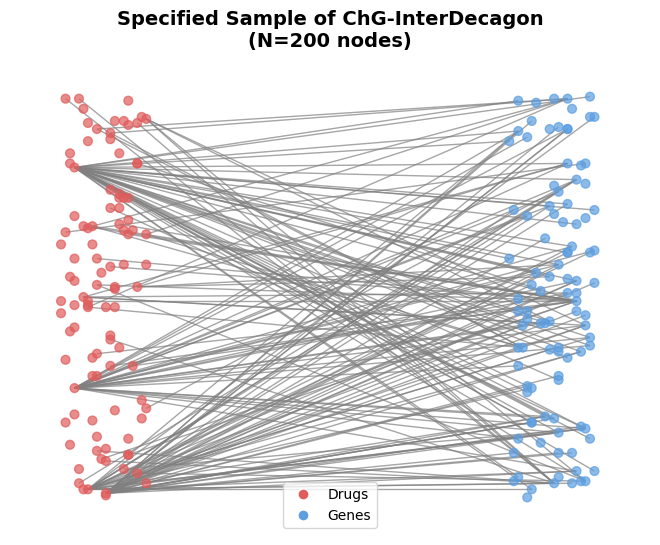

In [36]:


N = 100*2  # Number of drugs/genes to sample for visualization
S = N//2
sample_drugs = random.sample(list(drugs), S)
sample_genes = random.sample(list(genes), S)
sample_nodes = sample_drugs + sample_genes

subgraph = B.subgraph(sample_nodes)

# Build a color map aligned to the subgraph's node order
node_color = ['#e05c5c' if n in drugs else '#5c9ee0' for n in subgraph.nodes()]

pos = dict()
pos.update((n, (0 + random.randrange(-S//10, S//10), random.randrange(-S, S))) for n in sample_drugs)
pos.update((n, (S + random.randrange(-S//10, S//10), random.randrange(-S, S))) for n in sample_genes)

nx.draw(subgraph, pos=pos, with_labels=False, node_size=40,
        node_color=node_color, edge_color='gray', alpha=0.7)
plt.title(f'Specified Sample of ChG-InterDecagon\n(N={len(sample_nodes)} nodes)', fontsize=14, fontweight='bold')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e05c5c', markersize=8, label='Drugs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5c9ee0', markersize=8, label='Genes'),
]
plt.legend(handles=legend_elements, loc='lower center')
plt.show()

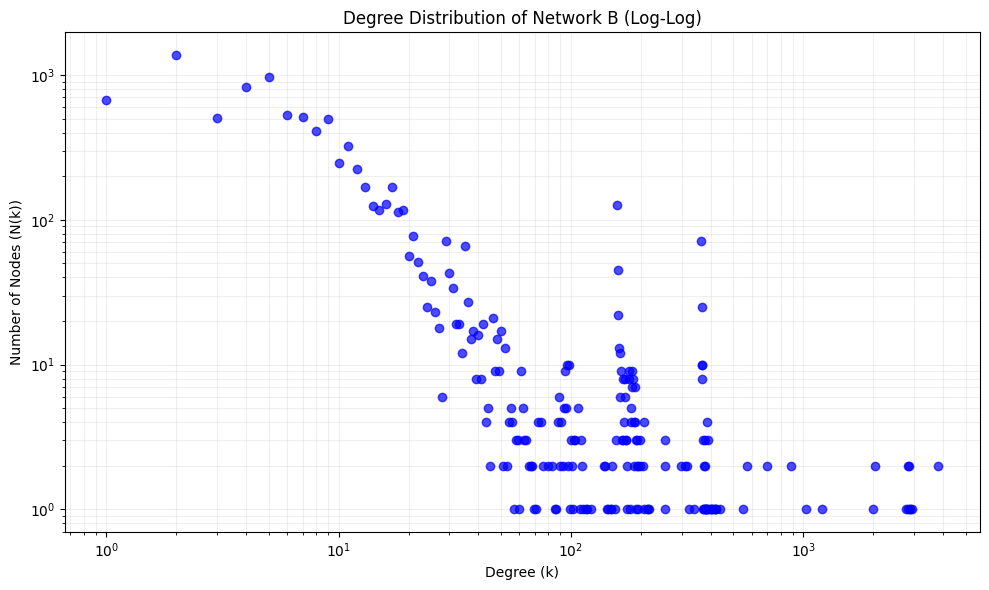

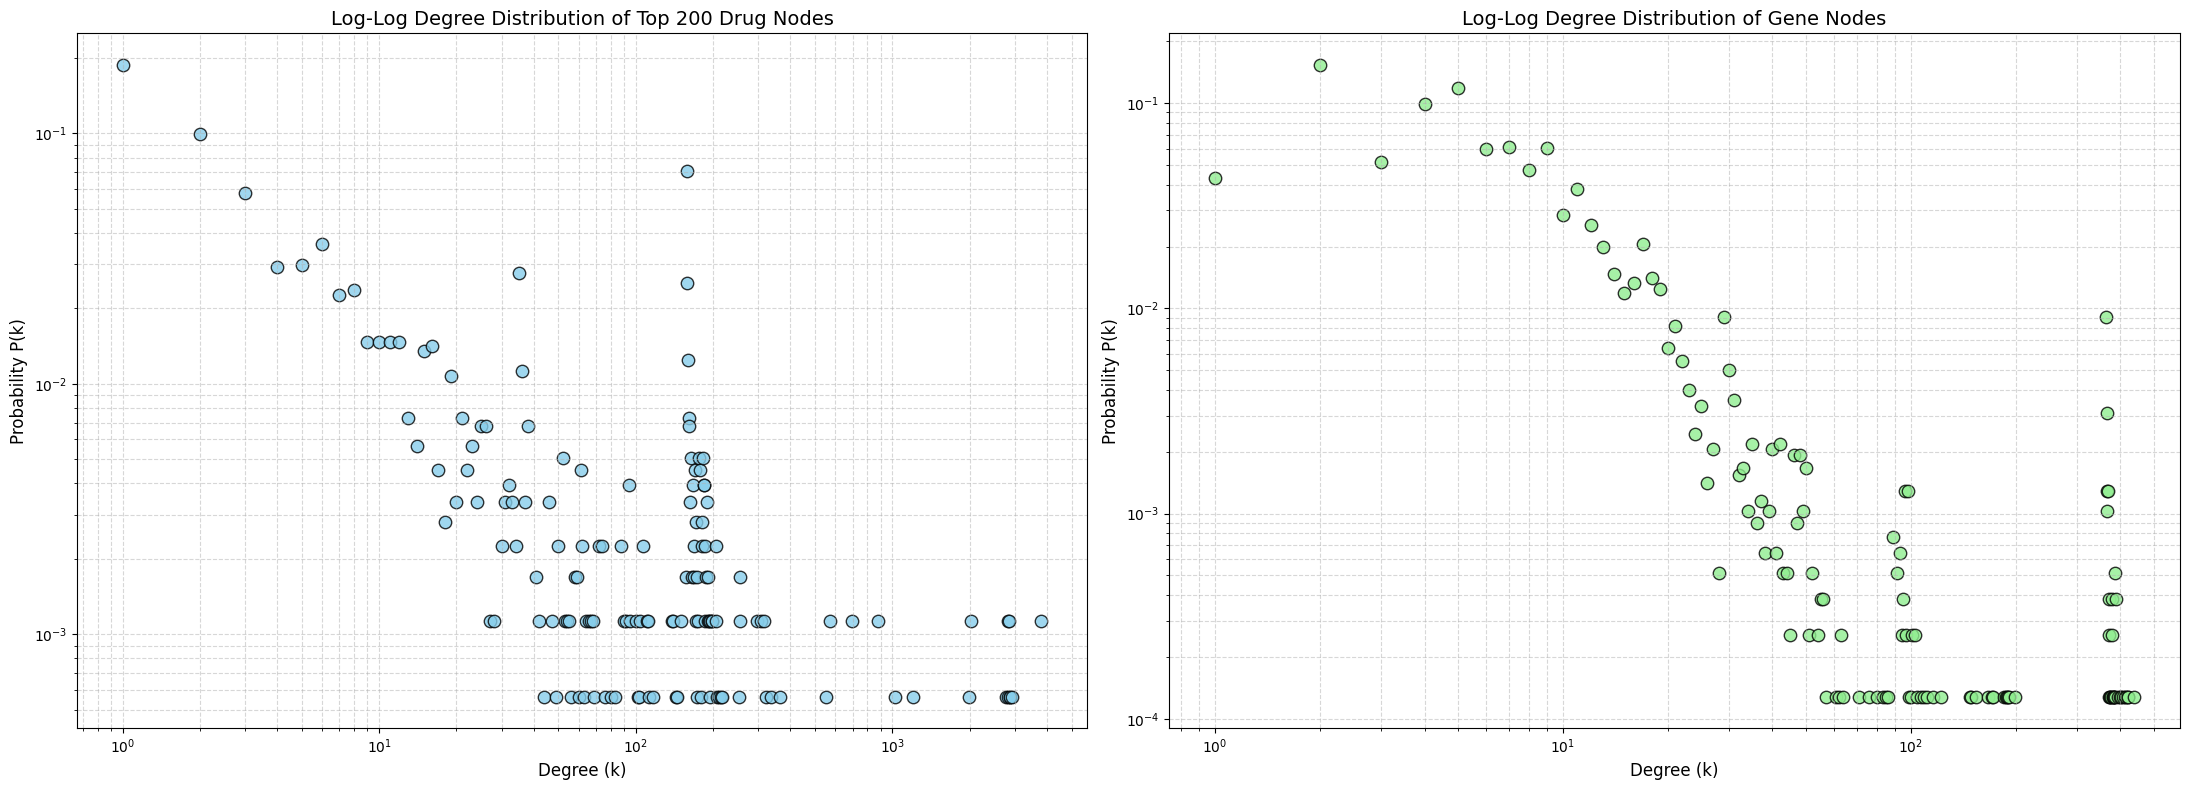

In [40]:
def degree_distribution_log_log(graph, title='Degree Distribution (Log-Log)'):
    """
    Plots the log-log degree distribution for the given graph.

    Args:
        graph (networkx.Graph): The networkx graph to analyze.
        title (str): The title for the plot.
    """
    # Get all degrees from the graph
    degrees = [d for n, d in graph.degree()]

    # Count the frequency of each degree
    degree_counts = collections.Counter(degrees)

    # Prepare data for plotting
    deg, cnt = zip(*degree_counts.items())

    # Convert to numpy arrays for log operations
    deg = np.array(deg)
    cnt = np.array(cnt)

    # Sort degrees and corresponding counts
    idx = np.argsort(deg)
    deg = deg[idx]
    cnt = cnt[idx]

    # Create the log-log plot
    plt.figure(figsize=(10, 6))
    plt.loglog(deg, cnt, 'o', color='blue', alpha=0.7)
    plt.title(title)
    plt.xlabel('Degree (k)')
    plt.ylabel('Number of Nodes (N(k))')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.tight_layout()
    plt.show()

# Example usage with your graph B:
degree_distribution_log_log(B, title='Degree Distribution of Network B (Log-Log)')


import collections
import matplotlib.pyplot as plt

def plot_degree_distribution(graph, drug_nodes, gene_nodes):
    """
    Draws the degree distribution of drugs and genes in a bipartite graph
    using log-log scaling.

    Args:
        graph (networkx.Graph): The bipartite graph.
        drug_nodes (list): A list of drug node identifiers.
        gene_nodes (list): A list of gene node identifiers.
    """
    all_degrees = dict(graph.degree())

    # Extract degrees for each set
    drug_degrees = [all_degrees[node] for node in drug_nodes if node in all_degrees]
    gene_degrees = [all_degrees[node] for node in gene_nodes if node in all_degrees]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

    # Helper function to compute degree probability distribution P(k)
    def get_degree_distribution(degrees):
        degree_counts = collections.Counter(degrees)
        total_nodes = len(degrees)
        # Sort by degree so the plot line/scatter flows sequentially
        sorted_degrees = sorted(degree_counts.keys())
        # Calculate P(k) = count / total
        probabilities = [degree_counts[k] / total_nodes for k in sorted_degrees]
        return sorted_degrees, probabilities

    # --- Plot for Drugs ---
    drug_k, drug_pk = get_degree_distribution(drug_degrees)
    ax1.scatter(drug_k, drug_pk, color='skyblue', edgecolor='black', alpha=0.8, s=80, label='Data')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_title('Log-Log Degree Distribution of Top 200 Drug Nodes', fontsize=14)
    ax1.set_xlabel('Degree (k)', fontsize=12)
    ax1.set_ylabel('Probability P(k)', fontsize=12)
    ax1.grid(True, which="both", ls="--", alpha=0.5)

    # --- Plot for Genes ---
    gene_k, gene_pk = get_degree_distribution(gene_degrees)
    ax2.scatter(gene_k, gene_pk, color='lightgreen', edgecolor='black', alpha=0.8, s=80, label='Data')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_title('Log-Log Degree Distribution of Gene Nodes', fontsize=14)
    ax2.set_xlabel('Degree (k)', fontsize=12)
    ax2.set_ylabel('Probability P(k)', fontsize=12)
    ax2.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# Call the function with the existing graph and node lists
plot_degree_distribution(B, drugs, genes)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import leidenalg as la
import igraph as ig
import numpy as np

# --- Build quotient graph ---
def make_quotient_graph(G, partition):
    Q = nx.Graph()
    Q.add_nodes_from(set(partition.values()))

    for u, v, data in G.edges(data=True):
        c_u, c_v = partition[u], partition[v]
        if c_u != c_v:
            if Q.has_edge(c_u, c_v):
                Q[c_u][c_v]['weight'] += 1
            else:
                Q.add_edge(c_u, c_v, weight=1)
    return Q

In [ ]:
# --- Run Leiden ---
G_ig = ig.Graph.from_networkx(B)
partition = la.find_partition(G_ig, la.ModularityVertexPartition)
membership = partition.membership
# --- Build partition dict ---
nx_nodes = list(B.nodes())
partition_dict = {nx_nodes[i]: membership[i] for i in range(len(nx_nodes))}

Q = make_quotient_graph(B, partition_dict)

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.circular_layout(Q)

community_sizes = {c: sum(1 for v in partition_dict.values() if v == c)
                   for c in Q.nodes()}

# Log-scaled node sizes to prevent giants swamping the layout
node_sizes = [300 * np.log1p(community_sizes[c]) for c in Q.nodes()]

cmap = plt.get_cmap('tab20', len(Q.nodes()))
colors = [cmap(i) for i, _ in enumerate(Q.nodes())]

edge_weights = [Q[u][v]['weight'] for u, v in Q.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [3 * w / max_w for w in edge_weights]

nx.draw_networkx_nodes(Q, pos, node_size=node_sizes, node_color=colors,
                       alpha=0.9, ax=ax)
#nx.draw_networkx_labels(Q, pos,
#                        labels={c: f'C{c}\n(n={community_sizes[c]})' for c in Q.nodes()},
#                        font_size=7, ax=ax)
nx.draw_networkx_edges(Q, pos, width=edge_widths, alpha=0.7,
                       edge_color='black', ax=ax)
#nx.draw_networkx_edge_labels(Q, pos,
#                             edge_labels={(u, v): Q[u][v]['weight'] for u, v in Q.edges()},
#                             font_size=6, ax=ax)

ax.set_title('Quotient Graph (communities as nodes)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# --- Run Leiden ---
G_ig = ig.Graph.from_networkx(B)
partition = la.find_partition(G_ig, la.ModularityVertexPartition)
membership = partition.membership
# --- Build partition dict ---
nx_nodes = list(B.nodes())
partition_dict = {nx_nodes[i]: membership[i] for i in range(len(nx_nodes))}

Q = make_quotient_graph(B, partition_dict)

In [ ]:
# Only show big/small communities (with >M/<=M members)
M = 30
big = False
if big:
    significant = {c for c, s in community_sizes.items() if s > M}
    Q = Q.subgraph(significant)
else:
    significant = {c for c, s in community_sizes.items() if s <= M}
    Q = Q.subgraph(significant)

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.circular_layout(Q)

community_sizes = {c: sum(1 for v in partition_dict.values() if v == c)
                   for c in Q.nodes()}

# Log-scaled node sizes to prevent giants swamping the layout
node_sizes = [550 * np.log1p(community_sizes[c]) for c in Q.nodes()]

cmap = plt.get_cmap('tab20', len(Q.nodes()))
colors = [cmap(i) for i, _ in enumerate(Q.nodes())]

edge_weights = [Q[u][v]['weight'] for u, v in Q.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [3 * w / max_w for w in edge_weights]

nx.draw_networkx_nodes(Q, pos, node_size=node_sizes, node_color=colors,
                       alpha=0.9, ax=ax)
nx.draw_networkx_labels(Q, pos,
                        labels={c: f'C{c}\n(n={community_sizes[c]})' for c in Q.nodes()},
                        font_size=12, ax=ax)
nx.draw_networkx_edges(Q, pos, width=edge_widths, alpha=0.7,
                       edge_color='black', ax=ax)
nx.draw_networkx_edge_labels(Q, pos,
                             edge_labels={(u, v): Q[u][v]['weight'] for u, v in Q.edges()},
                             font_size=10, ax=ax)

ax.set_title('Quotient Graph (communities as nodes)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def compare_node_neighborhoods(graph, node1, node2):
    if not graph.has_node(node1) or not graph.has_node(node2):
        print(f"\nError: One or both nodes ({node1}, {node2}) do not exist.")
        return

    set1 = set(graph.neighbors(node1))
    set2 = set(graph.neighbors(node2))

    deg1, deg2 = len(set1), len(set2)
    shared = set1.intersection(set2)
    unique_to_1 = set1 - set2
    unique_to_2 = set2 - set1
    total_union = set1.union(set2)

    jaccard = (len(shared) / len(total_union)) * 100 if total_union else 0.0
    pct_of_1_shared = (len(shared) / deg1) * 100 if deg1 else 0.0
    pct_of_2_shared = (len(shared) / deg2) * 100 if deg2 else 0.0

    print(f"\n=== Neighborhood Comparison: {node1} vs {node2} ===")
    print(f"{'Metric':<30} | {'Node 1 (' + node1 + ')':<25} | {'Node 2 (' + node2 + ')':<25}")
    print("-" * 88)
    print(f"{'Total Degree':<30} | {deg1:<25} | {deg2:<25}")
    print(f"{'% of own neighbors shared':<30} | {pct_of_1_shared:.2f}%{'':<24} | {pct_of_2_shared:.2f}%")
    print(f"Overall Neighborhood Similarity (Jaccard Index): {jaccard:.2f}%\n")

    def print_sample(title, data_set, sample_size=10):
        data_list = sorted(list(data_set))
        print(f"--- {title} (Total: {len(data_list)}) ---")
        if not data_list:
            print("  None")
        elif len(data_list) <= sample_size:
            print(f"  {', '.join(data_list)}")
        else:
            print(f"  {', '.join(data_list[:sample_size])} ... (+ {len(data_list) - sample_size} more)")
        print()


# Execute
node1_id = 'CID000000753'
node2_id = 'CID100000753'
compare_node_neighborhoods(G, node1_id, node2_id)

In [ ]:
def display_node_and_neighbors(graph, node_id):
    """
    Displays the immediate neighbors of a given node in a graph
    and visualizes the central node with its neighbors, decoding drug names.

    Args:
        graph (networkx.Graph): The graph object.
        node_id: The ID of the central node.
    """
    if not graph.has_node(node_id):
        print(f"Error: Node '{node_id}' not found in the graph.")
        return

    neighbors = list(graph.neighbors(node_id))

    # Load annotations for decoding (assuming load_annotations and decode_drug_cids are globally available)
    gene_name_map, drug_name_map = load_annotations()

    # Prepare labels for the central node and its neighbors
    labels = {}
    decoded_neighbors_display = []

    # Decode central node
    if str(node_id).startswith('CID'):
        # It's a drug
        decoded_name = decode_drug_cids([node_id], drug_name_map).get(node_id, node_id)
        labels[node_id] = decoded_name
    else:
        # It's a gene
        labels[node_id] = gene_name_map.get(str(node_id), node_id)

    # Decode neighbors
    for neighbor in neighbors:
        if str(neighbor).startswith('CID'):
            # It's a drug
            decoded_neighbor_name = decode_drug_cids([neighbor], drug_name_map).get(neighbor, neighbor)
            labels[neighbor] = decoded_neighbor_name
            decoded_neighbors_display.append(decoded_neighbor_name)
        else:
            # It's a gene
            decoded_neighbor_name = gene_name_map.get(str(neighbor), neighbor)
            labels[neighbor] = decoded_neighbor_name
            decoded_neighbors_display.append(decoded_neighbor_name)

    print(f"\n--- Neighbors for Node: {labels[node_id]} ---")
    print(f"Central Node: {labels[node_id]}")
    print(f"Immediate Neighbors ({len(neighbors)}): {', '.join(decoded_neighbors_display)}")
    print("--------------------------------------")

    # Visualization
    # Create a subgraph containing only the central node and its immediate neighbors
    nodes_to_draw = [node_id] + neighbors
    subgraph = graph.subgraph(nodes_to_draw)

    plt.figure(figsize=(10, 8)) # Increased figure size for better label readability
    pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42) # Layout for clear visualization

    # Draw nodes: central node in one color, neighbors in another
    node_colors = ['red' if node == node_id else 'turquoise' for node in subgraph.nodes()]
    nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=2000) # Increased node size

    # Draw edges
    nx.draw_networkx_edges(subgraph, pos, width=1.0, alpha=0.5, edge_color='gray')

    # Draw labels with decoded names
    nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=9, font_color='black')

    plt.title(f'Node: {labels[node_id]} and its Immediate Neighbors', size=15)
    plt.axis('off')
    plt.show()

# Example usage:
display_node_and_neighbors(G, '131')

In [38]:
metrics = calculate_network_metrics(B, drugs, genes)
component_info = analyze_components(B)
b_cent, c_cent, e_cent = centrality_measures(B)

--- Network Metrics (Bipartite) ---
Partition sizes: drugs=1774, genes=7795
Average Degree (all nodes): 27.38718779391786
Average Degree (drugs)    : 73.86358511837655
Average Degree (genes)    : 16.810006414368186
Bipartite Density         : 0.009475764607873836
Average Clustering        : 0.6694130855151247
-----------------------------------
--- Connected Components ---
Number of components      : 8
Largest component (nodes) : 9538
---------------------------
Computing Betweenness Centrality (Approximated)...
Average Betweenness Centrality: 0.0002038140869037001
Computing Closeness Centrality...
{'CID000060752': 0.21178791219701926, 'CID006918155': 0.26919549284861694, 'CID103052762': 0.24275646566468015, 'CID023668479': 0.28453711392029724, 'CID000028864': 0.32699599047033845, 'CID100003350': 0.29920683764952977, 'CID000060936': 0.28147041835084863, 'CID000003488': 0.3030219131989165, 'CID100000303': 0.31599575969694543, 'CID100005472': 0.3222516166298251, 'CID100005470': 0.3162691

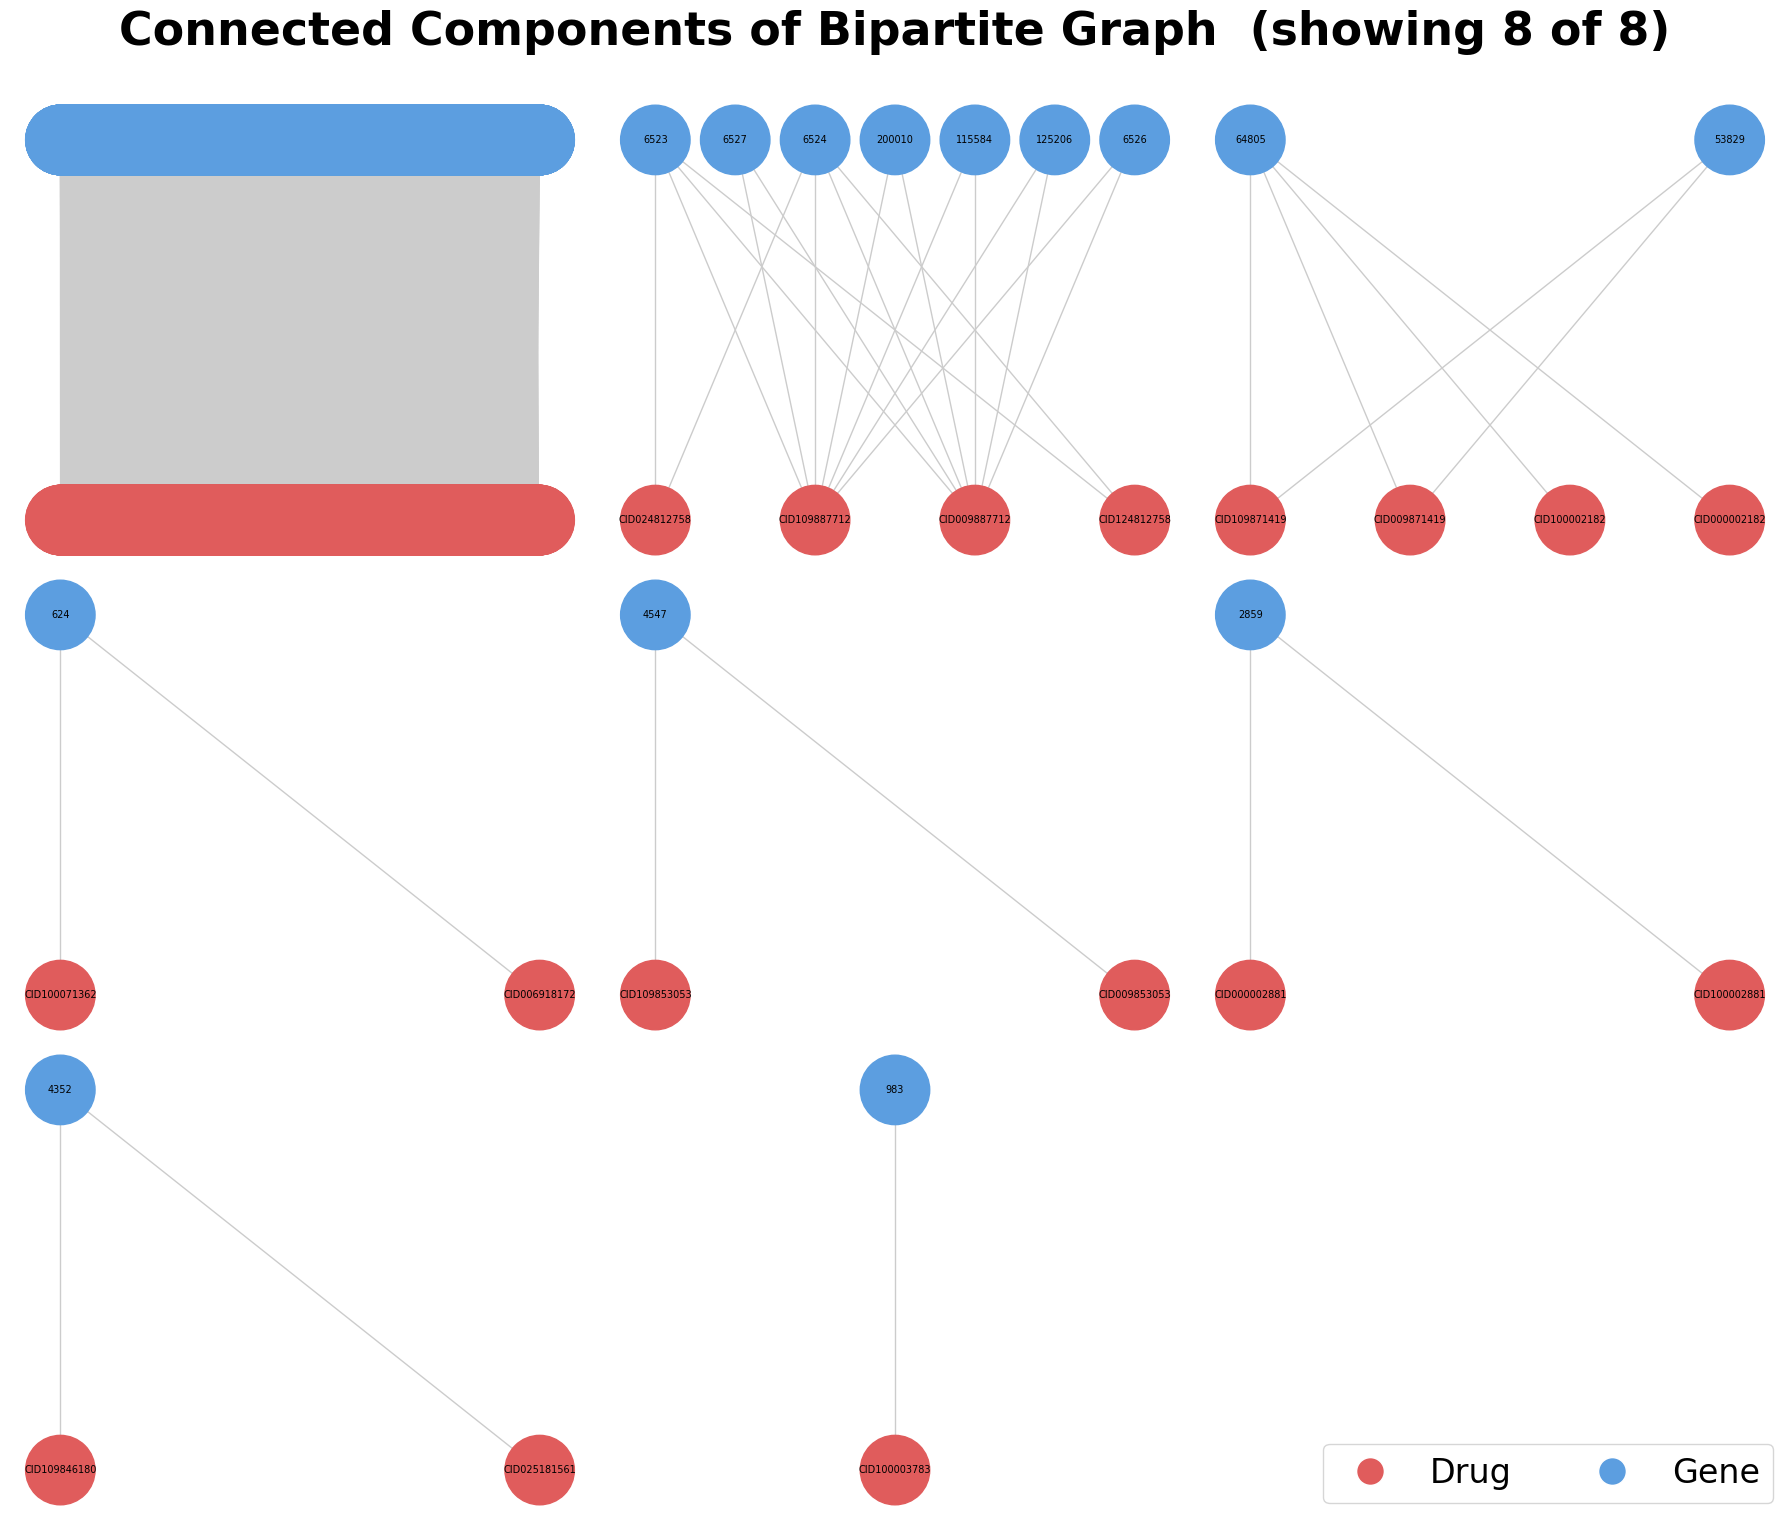

In [39]:
visualize_components(B, drugs, genes)